In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

In [7]:
df = pd.read_csv(r'C:\Users\Admin03\analysis_project_sales\Shopify-Sales-Intelligence\Dataset\shopify_products_clean (1).csv')

In [8]:
df.rename(columns={
    'Estimated_Total_Units_Sold_in_2025': 'Units_Sold',
    'Estimated_Revenue_in_2025_USD':      'Revenue_USD'
}, inplace=True)

In [9]:
df['Revenue_Per_Unit'] = df['Revenue_USD'] / df['Units_Sold']

In [10]:
df['Trend_Tier'] = pd.cut(
    df['Trend_Score'],
    bins=[0, 75, 85, 95, 100],
    labels=['Emerging (<75)', 'Rising (75-84)', 
            'Hot (85-94)', 'Viral (95+)']
)

In [11]:
print(df.shape)
print(df.dtypes)

(1000, 12)
Product_ID            object
Product_Name          object
Category              object
Subcategory           object
Units_Sold             int64
Revenue_USD          float64
Price_Range_USD       object
Trend_Score          float64
Trend_Source          object
Notes                 object
Revenue_Per_Unit     float64
Trend_Tier          category
dtype: object


In [ ]:
#Chart 1 — Category Revenue (answers Q1)

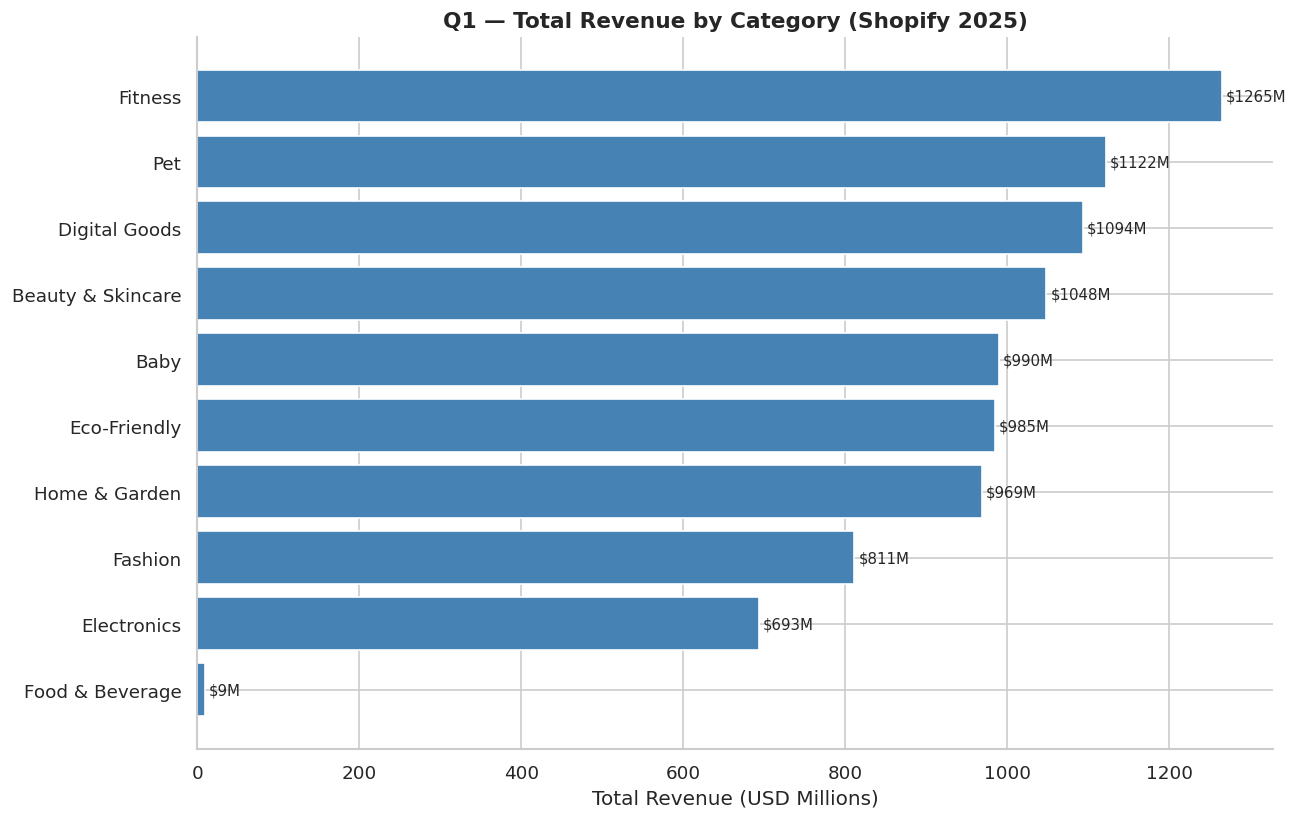

In [34]:
cat_rev = (
    df.groupby('Category')['Revenue_USD']
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)
cat_rev['Revenue_M'] = cat_rev['Revenue_USD'] / 1_000_000
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    cat_rev['Category'],
    cat_rev['Revenue_M'],
    color='steelblue',
    edgecolor='white'
)
for bar, val in zip(bars, cat_rev['Revenue_M']):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'${val:.0f}M',
        va='center', fontsize=9
    )
ax.set_xlabel('Total Revenue (USD Millions)')
ax.set_title('Q1 — Total Revenue by Category (Shopify 2025)',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Chart 2 — Trend Tier vs Profitability (answers Q2)

In [20]:
tier_order = ['Emerging (<75)', 'Rising (75-84)', 
              'Hot (85-94)', 'Viral (95+)']


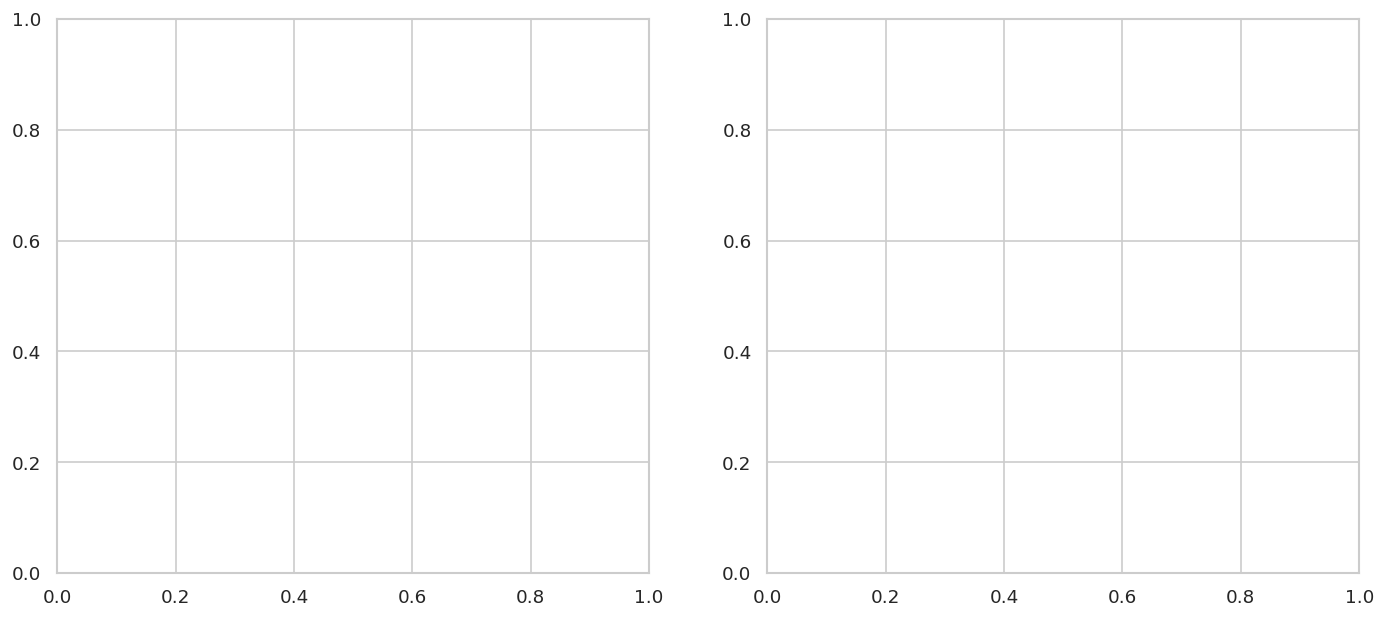

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


In [ ]:
# Left panel — Revenue Per Unit


In [ ]:
# Right panel — Units Sold


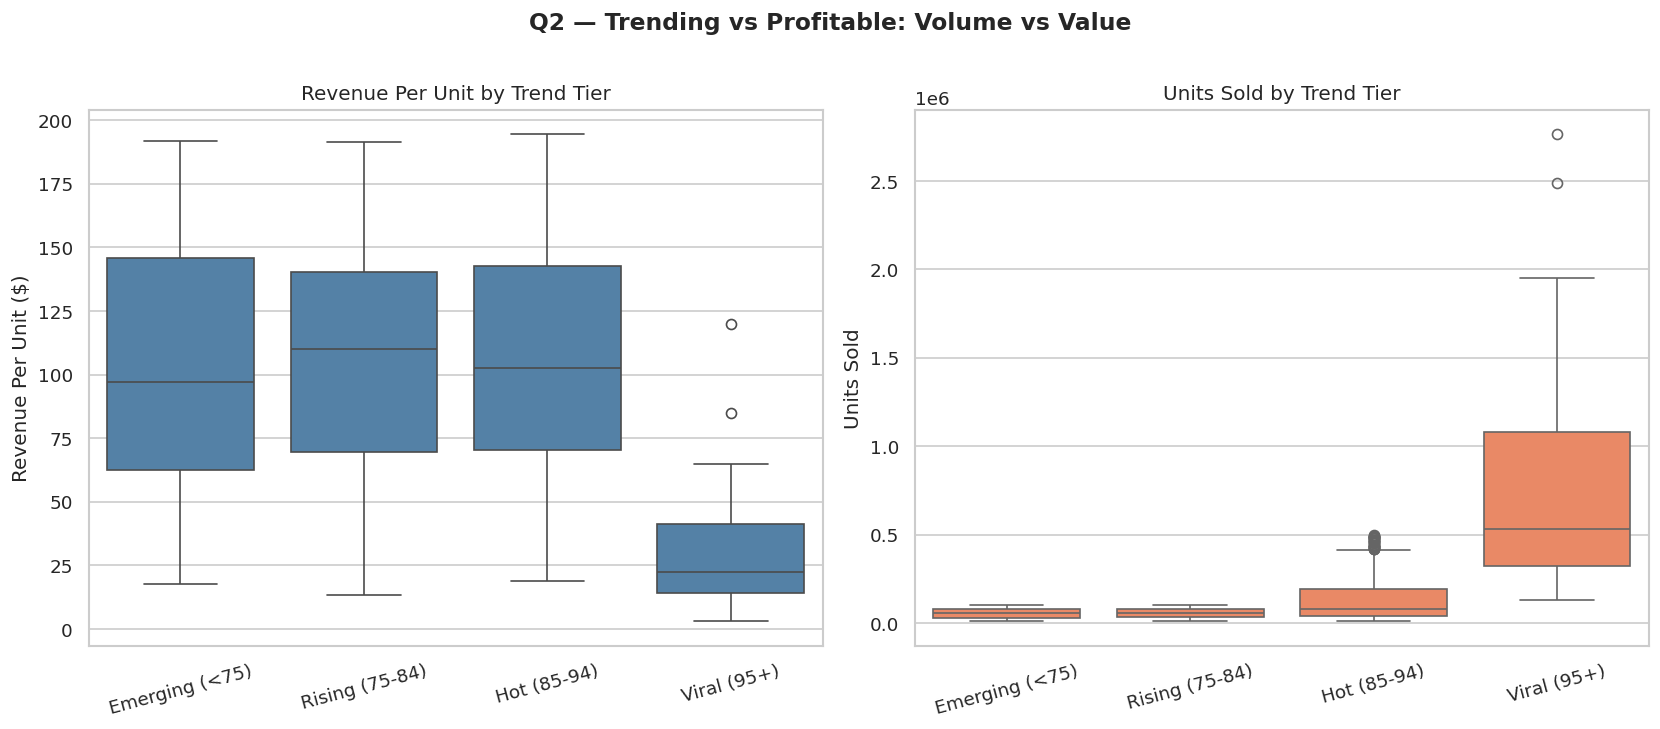

In [29]:
tier_order = ['Emerging (<75)', 'Rising (75-84)', 
              'Hot (85-94)', 'Viral (95+)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df, x='Trend_Tier', y='Revenue_Per_Unit',
    order=tier_order, color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Revenue Per Unit by Trend Tier')
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue Per Unit ($)')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(
    data=df, x='Trend_Tier', y='Units_Sold',
    order=tier_order, color='coral',
    ax=axes[1]
)
axes[1].set_title('Units Sold by Trend Tier')
axes[1].set_xlabel('')
axes[1].set_ylabel('Units Sold')
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle(
    'Q2 — Trending vs Profitable: Volume vs Value',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('chart2_trend_vs_profit.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
Chart 3 — Pre Peak Opportunity Scatter (answers Q3)

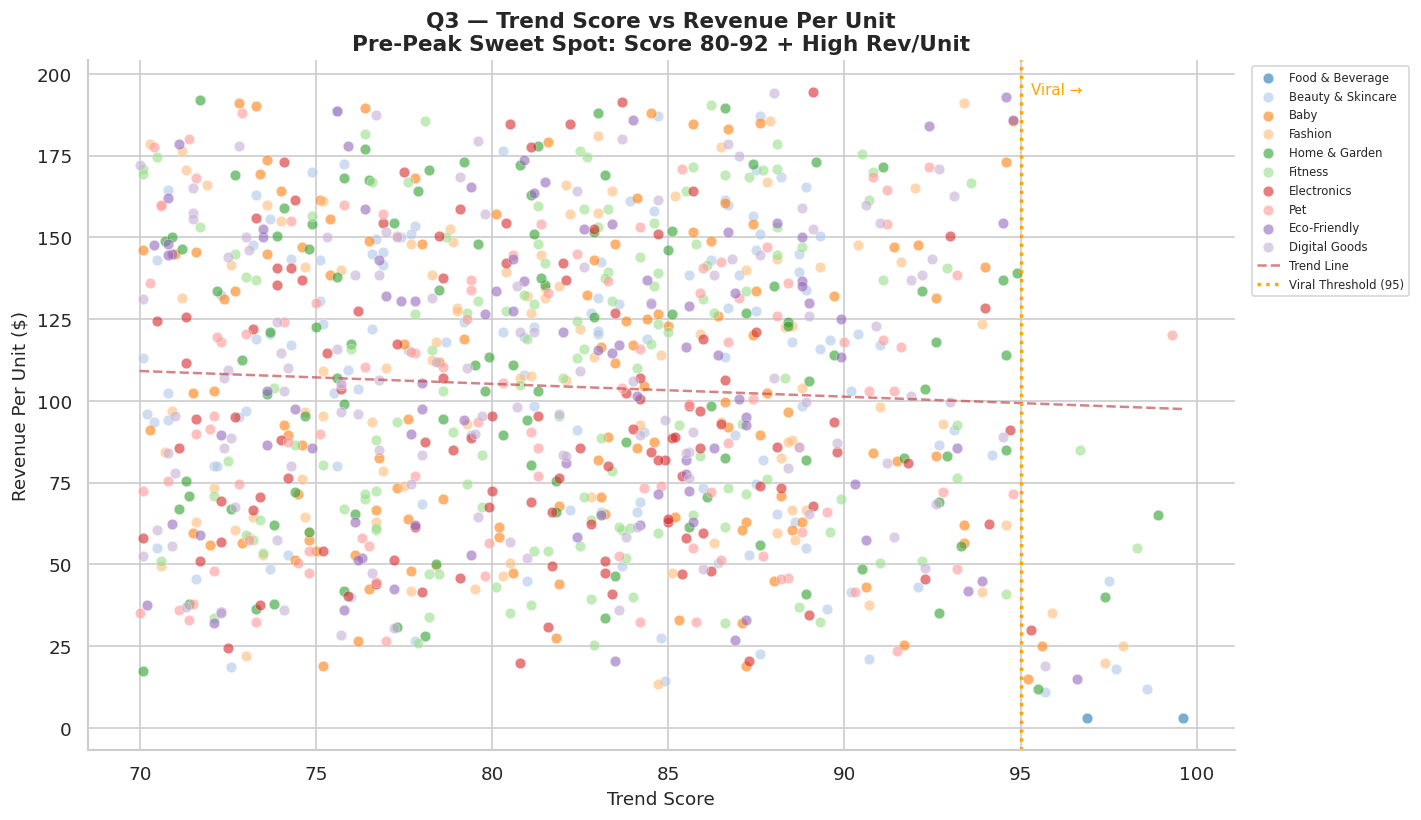

In [28]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each category as different colour
categories = df['Category'].unique()
palette = sns.color_palette('tab20', len(categories))

for cat, color in zip(categories, palette):
    subset = df[df['Category'] == cat]
    ax.scatter(
        subset['Trend_Score'],
        subset['Revenue_Per_Unit'],
        label=cat,
        color=color,
        alpha=0.6,
        s=40,
        edgecolors='white',
        linewidth=0.3
    )

# Trendline
valid = df.dropna(subset=['Trend_Score', 'Revenue_Per_Unit'])
z = np.polyfit(valid['Trend_Score'], valid['Revenue_Per_Unit'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Trend_Score'].min(), 
                      df['Trend_Score'].max(), 200)
ax.plot(x_line, p(x_line), 'r--', 
        linewidth=1.5, label='Trend Line', alpha=0.7)

# Viral threshold line
ax.axvline(x=95, color='orange', linestyle=':', 
           linewidth=2, label='Viral Threshold (95)')
ax.text(95.3, ax.get_ylim()[1] * 0.95, 
        'Viral →', color='orange', fontsize=9)

ax.set_xlabel('Trend Score', fontsize=11)
ax.set_ylabel('Revenue Per Unit ($)', fontsize=11)
ax.set_title('Q3 — Trend Score vs Revenue Per Unit\n'
             'Pre-Peak Sweet Spot: Score 80-92 + High Rev/Unit',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(bbox_to_anchor=(1.01, 1), 
          loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig('chart3_prepeak_scatter.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Heatmap: Category vs Trend Source


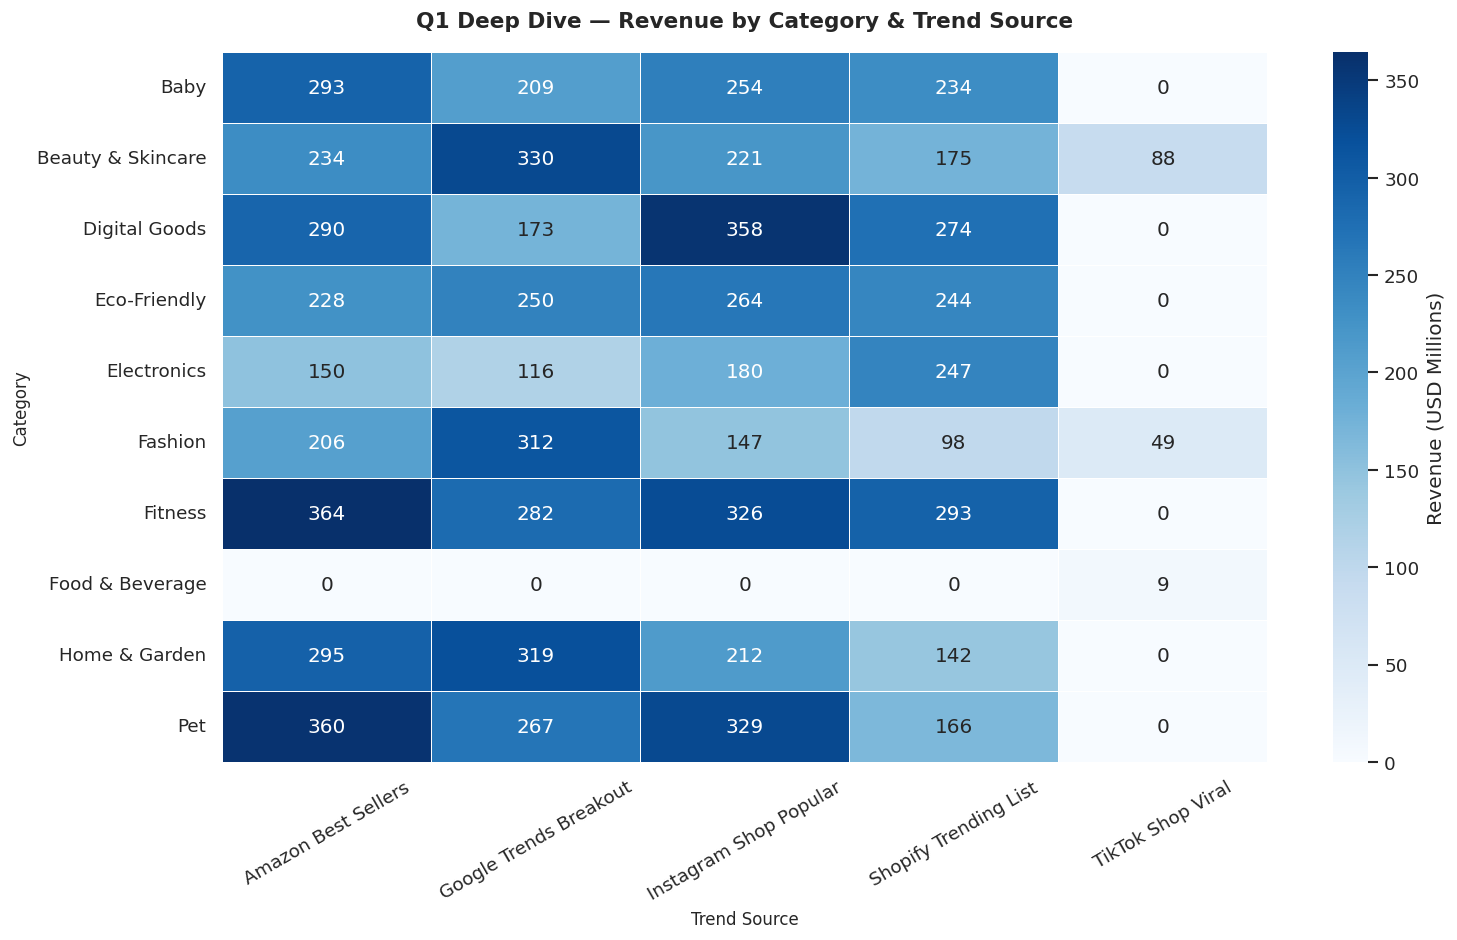

In [31]:
heatmap_data = (
    df.groupby(['Category', 'Trend_Source'])['Revenue_USD']
    .sum()
    .unstack(fill_value=0)
)
heatmap_data = heatmap_data / 1_000_000

fig, ax = plt.subplots(figsize=(13, 8))

sns.heatmap(
    heatmap_data,
    annot=True, fmt='.0f',
    cmap='Blues',
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Revenue (USD Millions)'}
)

ax.set_title('Q1 Deep Dive — Revenue by Category & Trend Source',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Trend Source', fontsize=10)
ax.set_ylabel('Category', fontsize=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
#Chart 5 — Correlation Matrix

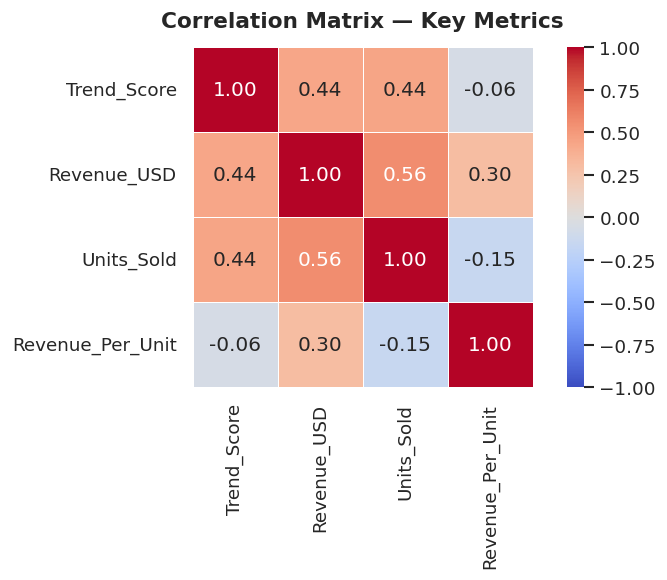

Trend Score vs Revenue Per Unit: r = -0.060

Interpretation:
  r close to 0  = no relationship
  r close to 1  = strong positive
  r close to -1 = strong negative



In [32]:
from scipy import stats

# Select numeric columns
numeric_cols = ['Trend_Score', 'Revenue_USD', 
                'Units_Sold', 'Revenue_Per_Unit']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    ax=ax, square=True,
    linewidths=0.5,
    vmin=-1, vmax=1
)

ax.set_title('Correlation Matrix — Key Metrics',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('chart5_correlation.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Print interpretation
r, p = stats.pearsonr(
    df.dropna()['Trend_Score'], 
    df.dropna()['Revenue_Per_Unit']
)
print(f'Trend Score vs Revenue Per Unit: r = {r:.3f}')
print()
print('Interpretation:')
print('  r close to 0  = no relationship')
print('  r close to 1  = strong positive')
print('  r close to -1 = strong negative')
print()